# Setup and Data Loading

In [ ]:
# =============================================================
# 🧠 Task 1: Multi-Class Dysarthria Severity Classification
# Data Loading + Preprocessing Notebook - Train Set
# =============================================================
import os
import pandas as pd
import numpy as np
import librosa
import soundfile as sf
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1️. Install Required Libraries (Typically uncommented for initial run)
# NOTE: Assuming you ran this, so keeping it commented for efficiency.
# !pip install pandas numpy librosa soundfile matplotlib seaborn tqdm openpyxl praat-parselmouth joblib

# --- 2. Define Paths and Load Metadata ---
# NOTE: Based on your provided paths, we define the base directory for 'Train/task1'.
# We need to adapt the path based on where you are running the notebook.
# For local execution, ensure this BASE_DIR variable is correct.
# Assuming the notebook is in 'Multimodal_Project' and data is in 'Train/task1'
# Let's use a relative path structure that should work if the notebook is run
# from the 'Multimodal_Project' directory, but since you provided absolute paths,
# I'll use a placeholder structure based on your folder image.

# Placeholder BASE_DIR - ***Please replace the start of this path with your absolute path***
# Example: BASE_DIR = r"C:\Users\vaish\OneDrive\Desktop\Sem 5\Multi Modal\Project\Multimodal_Project\Train\task1"
# For now, I will use a relative path that aligns with the previous notebook structure,
# assuming the notebook is run from the directory *above* "Train".
BASE_DIR = r"Train/task1"
META_PATH = os.path.join(BASE_DIR, "sand_task_1.xlsx")
TRAIN_DIR = os.path.join(BASE_DIR, "training")
os.makedirs(TRAIN_DIR, exist_ok=True) # Ensure existence of 'training' subfolder

print(f"Base Directory Set to: {BASE_DIR}")
print("-" * 30)

# --- Load Metadata ---
try:
    metadata = pd.read_excel(META_PATH)
    # Strip whitespace from ID column (important for matching file IDs)
    metadata["ID"] = metadata["ID"].astype(str).str.strip()
    valid_ids = set(metadata["ID"].values)
    print("✅ Metadata Loaded.")
except FileNotFoundError:
    print(f"❌ ERROR: Metadata file not found at {META_PATH}")
    exit()

# --- Create DataFrame Linking Audio Paths with Metadata ---
audio_data = []
# Folders inside 'training' are the 'Task' types (e.g., phonationA, rhythmKA)
folders = sorted(os.listdir(TRAIN_DIR))

# Process all audio files and link with metadata
for folder in tqdm(folders, desc="Linking Train Audio"):
    folder_path = os.path.join(TRAIN_DIR, folder)
    if not os.path.isdir(folder_path): continue
    for file in os.listdir(folder_path):
        if file.lower().endswith(".wav"):
            # Extract ID (e.g., 'ID000' from 'ID000_phonationA.wav')
            file_id = file.split("_")[0]
            if file_id in valid_ids:
                row = metadata[metadata["ID"] == file_id].iloc[0]
                audio_data.append({
                    "ID": file_id,
                    "Age": row["Age"],
                    "Sex": row["Sex"],
                    "Class": row["Class"],
                    "Task": folder,
                    "Filepath": os.path.join(folder_path, file)
                })

audio_df = pd.DataFrame(audio_data)
# Save combined dataset (initial)
audio_df.to_csv(os.path.join(BASE_DIR, "audio_metadata_train_raw.csv"), index=False)
print(f"\n✅ Train DataFrame Created (Rows: {len(audio_df)}). Raw CSV saved.")
print("\n--- DataFrame Head and Info ---")
print(audio_df.head())
print("\n--- Data Types ---")
print(audio_df.info())

Base Directory Set to: Train/task1
------------------------------
✅ Metadata Loaded.


Linking Train Audio: 100%|██████████| 8/8 [00:00<00:00, 22.25it/s]


✅ Train DataFrame Created (Rows: 2176). Raw CSV saved.

--- DataFrame Head and Info ---
      ID  Age Sex  Class        Task  \
0  ID000   80   M      5  phonationA   
1  ID001   61   F      5  phonationA   
2  ID002   51   F      4  phonationA   
3  ID003   59   M      3  phonationA   
4  ID005   80   F      5  phonationA   

                                            Filepath  
0  Train/task1\training\phonationA\ID000_phonatio...  
1  Train/task1\training\phonationA\ID001_phonatio...  
2  Train/task1\training\phonationA\ID002_phonatio...  
3  Train/task1\training\phonationA\ID003_phonatio...  
4  Train/task1\training\phonationA\ID005_phonatio...  

--- Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2176 entries, 0 to 2175
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ID        2176 non-null   object
 1   Age       2176 non-null   int64 
 2   Sex       2176 non-null   object
 3   Class     2176 non-

# Exploratory Data Analysis (EDA) and Duration Calculation

In [9]:
# --- 3. Exploratory Data Analysis (EDA) & Duration Calculation ---
print("\n--- Basic Dataset Info ---")
print(f"Total rows: {audio_df.shape[0]}")
print("Class Distribution:\n", audio_df['Class'].value_counts().sort_index())

# Calculate Duration (using efficient soundfile/librosa logic)
if 'Duration_s' not in audio_df.columns:
    durations = []
    # Use Filepath column from the previous step
    path_col = 'Filepath' 
    for p in tqdm(audio_df[path_col].values, desc="Computing Train Durations"):
        try:
            # Try efficient soundfile info method first
            info = sf.info(p)
            durations.append(float(info.duration))
        except Exception:
            # Fallback to slower librosa load
            try:
                # Load with sr=None to get original sample rate
                y, sr_ = librosa.load(p, sr=None)
                durations.append(float(len(y) / sr_))
            except Exception:
                durations.append(np.nan) # Mark as missing
                
    audio_df['Duration_s'] = durations
    print("\n✅ Audio Durations Computed.")

# Summary statistics
print("\nAge Summary (years):\n", audio_df['Age'].describe())
print("\nDuration Summary (seconds):\n", audio_df['Duration_s'].describe())

# Calculate Spearman Correlation
audio_df['Class_num'] = audio_df['Class'].astype(int) # Ensure numeric class for correlation
corr_age_class_dur = audio_df[['Age','Class_num','Duration_s']].corr(method='spearman')
print("\nSpearman Correlation (Age, Class, Duration):\n", corr_age_class_dur)

# Per-class aggregations
agg = audio_df.groupby('Class_num').agg(
    samples=('ID','count'),
    mean_age=('Age','mean'),
    mean_duration=('Duration_s','mean')
).sort_index()

# Save EDA summary
agg.to_csv(os.path.join(BASE_DIR, "per_class_summary_train_raw.csv"), index=True)
print("\n💾 Per-class summary saved.")


--- Basic Dataset Info ---
Total rows: 2176
Class Distribution:
 1     48
2    208
3    456
4    608
5    856
Name: Class, dtype: int64


Computing Train Durations: 100%|██████████| 2176/2176 [00:02<00:00, 899.67it/s]


✅ Audio Durations Computed.

Age Summary (years):
 count    2176.000000
mean       63.514706
std        11.258949
min        23.000000
25%        56.750000
50%        64.500000
75%        72.000000
max        89.000000
Name: Age, dtype: float64

Duration Summary (seconds):
 count    2176.000000
mean       13.818564
std         7.355231
min         0.720000
25%         8.480000
50%        12.400000
75%        17.930000
max        48.240000
Name: Duration_s, dtype: float64

Spearman Correlation (Age, Class, Duration):
                  Age  Class_num  Duration_s
Age         1.000000  -0.020064   -0.226279
Class_num  -0.020064   1.000000    0.298478
Duration_s -0.226279   0.298478    1.000000

💾 Per-class summary saved.


# Audio Standardization and Manifest Creation

In [10]:
# --- 4. Cleaning & Standardization (8kHz Mono PCM_16) ---
import hashlib
import os
import pandas as pd
import librosa
import soundfile as sf
from tqdm import tqdm

# Redefine BASE_DIR for clarity in this chunk
BASE_DIR = r"Train/task1"
CLEAN_DIR = os.path.join(BASE_DIR, "cleaned_wavs")
os.makedirs(CLEAN_DIR, exist_ok=True)
print(f"Created clean directory: {CLEAN_DIR}")

# Reload the DataFrame created in step 2 (audio_df) and ensure types
# In a standard notebook flow, audio_df is already defined.
# If running this chunk standalone, you might need to reload the raw CSV.
try:
    if 'audio_df' not in locals():
        audio_df = pd.read_csv(os.path.join(BASE_DIR, "audio_metadata_train_raw.csv"))
except FileNotFoundError:
    print("❌ ERROR: Missing 'audio_metadata_train_raw.csv'. Cannot proceed.")
    exit()
    
# Ensure columns are correctly formatted for processing
audio_df['Filepath'] = audio_df['Filepath'].apply(lambda p: os.path.normpath(p).replace('\\\\', '/'))
audio_df['Class'] = audio_df['Class'].astype(int) 
audio_df['Age'] = audio_df['Age'].astype(int)
audio_df['Sex'] = audio_df['Sex'].astype(str)

manifests = []
# Process and re-encode all files
for _, row in tqdm(audio_df.iterrows(), total=len(audio_df), desc="Standardizing Train Audio"):
    src = row['Filepath']
    try:
        # Load and resample to 8kHz mono
        # NOTE: Librosa handles resampling/downmixing here automatically
        y, sr_ = librosa.load(src, sr=8000, mono=True)
        duration = float(len(y) / 8000.0)
        
        # Define output path and write PCM_16 8kHz mono
        out_name = f"{row['ID']}_{row['Task']}.wav"
        out_path = os.path.join(CLEAN_DIR, out_name)
        
        # NOTE: Using 'PCM_16' subtype ensures compatibility and reduces size from original high quality files
        sf.write(out_path, y, 8000, subtype='PCM_16')
        
        # Compute SHA256 checksum
        h = hashlib.sha256()
        with open(out_path, 'rb') as fh:
            # Use chunks for large files (though unlikely needed here)
            for chunk in iter(lambda: fh.read(8192), b""):
                h.update(chunk)
        sha256 = h.hexdigest()
        
        manifests.append({
            'ID': row['ID'], 'Task': row['Task'], 'Class': int(row['Class']), 
            'Age': int(row['Age']), 'Sex': row['Sex'], 'OriginalPath': src,
            # Use relative path for easier project portability
            'RelPath': os.path.relpath(out_path, BASE_DIR).replace('\\\\', '/'),
            'Duration_s': round(duration, 4),
            'Samplerate': 8000, 'Channels': 1, 'Subtype': 'PCM_16', 
            'SHA256': sha256
        })
    except Exception as e:
        # Simple error reporting to keep loop moving
        # print(f"Failed to process {src}: {e}")
        pass # Silently skip failed files

manifest_df = pd.DataFrame(manifests)
manifest_fp = os.path.join(BASE_DIR, "manifest.csv")
clean_meta_fp = os.path.join(BASE_DIR, "cleaned_metadata.csv")

# Save manifests
manifest_df.to_csv(manifest_fp, index=False)
# Save a smaller version for quick reference
manifest_df[['ID','Age','Sex','Class','Task','RelPath','Duration_s']].to_csv(clean_meta_fp, index=False)

print(f"\n✅ Manifest successfully rebuilt and saved: {manifest_fp}")

Created clean directory: Train/task1\cleaned_wavs


Standardizing Train Audio:   0%|          | 0/2176 [00:00<?, ?it/s]c:\Users\vibha\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,
Standardizing Train Audio: 100%|██████████| 2176/2176 [00:28<00:00, 75.45it/s]



✅ Manifest successfully rebuilt and saved: Train/task1\manifest.csv


# Voice Activity Detection (VAD) and Feature Extraction

In [11]:
# --- 5. Voice Activity Detection (VAD) Helper Function ---
import os
import pandas as pd
import numpy as np
import librosa
from tqdm import tqdm

# Redefine BASE_DIR and load manifest for this step
BASE_DIR = r"Train/task1"
MANIFEST_PATH = os.path.join(BASE_DIR, "manifest.csv")
df = pd.read_csv(MANIFEST_PATH)

def detect_speech_intervals(y, sr, frame_ms=30, hop_ms=10,
                            min_speech_ms=200, min_silence_ms=150,
                            energy_multiplier=3.0):
    """Simple energy-based VAD with smoothing. Returns list of (start_s, end_s) speech intervals."""
    frame_len = max(2, int(sr * frame_ms / 1000))
    hop_len = max(1, int(sr * hop_ms / 1000))
    
    # RMS energy calculation
    rms = librosa.feature.rms(y=y, frame_length=frame_len, hop_length=hop_len)[0]
    times = librosa.frames_to_time(np.arange(len(rms)), sr=sr, hop_length=hop_len, n_fft=frame_len)
    
    # Robust threshold: median + energy_multiplier * MAD
    med = np.median(rms)
    mad = np.median(np.abs(rms - med)) if len(rms) > 0 else 0.0
    thresh = med + energy_multiplier * mad
    if thresh <= 0:
        thresh = np.percentile(rms, 50) + 1e-9 # Fallback threshold
    mask = rms >= thresh

    # Smoothing (Fill short silences / Remove short speech bursts)
    min_speech_frames = max(1, int(np.ceil(min_speech_ms / hop_ms)))
    min_silence_frames = max(1, int(np.ceil(min_silence_ms / hop_ms)))

    # Fill short silences (bridge)
    i = 0
    while i < len(mask):
        if not mask[i]:
            j = i
            while j < len(mask) and not mask[j]: j += 1
            gap = j - i
            if 0 < gap <= min_silence_frames and i > 0 and j < len(mask):
                mask[i:j] = True
            i = j
        else:
            i += 1

    # Remove short speech segments
    i = 0
    while i < len(mask):
        if mask[i]:
            j = i
            while j < len(mask) and mask[j]: j += 1
            length = j - i
            if length < min_speech_frames:
                mask[i:j] = False
            i = j
        else:
            i += 1

    # Convert mask to time intervals (seconds)
    intervals = []
    i = 0
    while i < len(mask):
        if mask[i]:
            j = i
            while j < len(mask) and mask[j]: j += 1
            start = times[i]
            # End time approximation (add frame size)
            end = times[min(j - 1, len(times) - 1)] + frame_ms / 1000.0
            intervals.append((max(0.0, float(start)), float(end)))
            i = j
        else:
            i += 1
    return intervals

print("✅ VAD function defined (detect_speech_intervals).")
print("-" * 50)


# --- 6. Apply VAD and Extract Timing Features to Manifest ---
SAVED_VAD_CSV = os.path.join(BASE_DIR, "manifest_with_vad.csv")

# Initialize VAD columns 
vad_cols = ['speech_intervals', 'speech_duration_s', 'speech_ratio',
            'num_speech_segments', 'mean_speech_segment_s', 'mean_silence_between_s']
for col in vad_cols:
    if col not in df.columns:
        df[col] = None

# Process each cleaned file
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Running VAD on Train Data"):
    rel = row['RelPath']
    # NOTE: The base directory for RelPath is BASE_DIR itself
    full = os.path.normpath(os.path.join(BASE_DIR, rel))
    
    try:
        # Load the *cleaned* audio at 8000 Hz (standardized in step 3)
        y, sr = librosa.load(full, sr=8000, mono=True)
        intervals = detect_speech_intervals(y, sr)
        
        speech_durs = [e - s for s, e in intervals]
        total_speech = float(np.sum(speech_durs)) if speech_durs else 0.0
        duration = float(row.get('Duration_s'))
        speech_ratio = total_speech / duration if duration > 0 else 0.0
        num_segments = len(speech_durs)
        mean_seg = float(np.mean(speech_durs)) if speech_durs else 0.0
        
        mean_sil = 0.0
        if num_segments > 1:
            # Silence duration calculation
            silences = [intervals[i][0] - intervals[i-1][1] for i in range(1, len(intervals))]
            mean_sil = float(np.mean(silences)) if silences else 0.0

        df.at[idx, 'speech_intervals'] = str(intervals) # Save as string
        df.at[idx, 'speech_duration_s'] = round(total_speech, 4)
        df.at[idx, 'speech_ratio'] = round(speech_ratio, 4)
        df.at[idx, 'num_speech_segments'] = int(num_segments)
        df.at[idx, 'mean_speech_segment_s'] = round(mean_seg, 4)
        df.at[idx, 'mean_silence_between_s'] = round(mean_sil, 4)
        
    except Exception as e:
        # print(f"VAD failed for {full}: {e}")
        pass

df.to_csv(SAVED_VAD_CSV, index=False)
print(f"\n✅ VAD processing complete.")
print(f"💾 Manifest with VAD saved to: {SAVED_VAD_CSV}")

# Display VAD summary (aggregated diagnostics)
diag = df.groupby('Class').agg(
    samples=('ID','count'),
    mean_speech_ratio=('speech_ratio','mean'),
    mean_num_segments=('num_speech_segments','mean'),
).round(4)
print("\n--- VAD Summary (Per-Class Averages) ---")
print(diag)

✅ VAD function defined (detect_speech_intervals).
--------------------------------------------------


Running VAD on Train Data: 100%|██████████| 2176/2176 [00:03<00:00, 580.02it/s]


✅ VAD processing complete.
💾 Manifest with VAD saved to: Train/task1\manifest_with_vad.csv

--- VAD Summary (Per-Class Averages) ---
       samples  mean_speech_ratio  mean_num_segments
Class                                               
1           48             0.1869             2.1042
2          208             0.1266             1.5337
3          456             0.0906             2.5570
4          608             0.1119             3.3322
5          856             0.1374             2.9416


# RMS Volume Normalization (-20 dBFS Target)

In [12]:
# --- 7. RMS Volume Normalization (-20 dBFS Target) ---
import os
import pandas as pd
import numpy as np
import soundfile as sf
import hashlib
import shutil 
from tqdm import tqdm

# Redefine BASE_DIR and load manifest for this step
BASE_DIR = r"Train/task1"
INPUT_VAD_MANIFEST = os.path.join(BASE_DIR, "manifest_with_vad.csv")
df_manifest = pd.read_csv(INPUT_VAD_MANIFEST)

NORMALIZED_DIR = os.path.join(BASE_DIR, "normalized_wavs")
os.makedirs(NORMALIZED_DIR, exist_ok=True)
print(f"Created normalized directory: {NORMALIZED_DIR}")

# --- Normalization Parameters ---
TARGET_DBFS = -20.0
# Target RMS is calculated from dBFS: 10^(dBFS / 20)
TARGET_RMS = 10.0 ** (TARGET_DBFS / 20.0) 

# Prepare new columns
for col in ('NormRelPath', 'NormSHA256', 'NormRMS_db', 'NormPeak', 'NormScale'):
    if col not in df_manifest.columns:
        df_manifest[col] = None

num_scaled_by_peak = 0

for idx, row in tqdm(df_manifest.iterrows(), total=len(df_manifest), desc="Normalizing Train Audio"):
    # Use the path to the *cleaned* audio from the previous step
    rel = row['RelPath']
    src_fp = os.path.normpath(os.path.join(BASE_DIR, rel))
    
    try:
        # Read as float32 (-1..1 range)
        y, sr = sf.read(src_fp, dtype='float32')
        if y.ndim > 1: y = np.mean(y, axis=1) # Ensure mono
        
        rms = float(np.sqrt(np.mean(np.square(y)))) if y.size > 0 else 0.0
        orig_db = 20.0 * np.log10(rms + 1e-12)
        
        scale = 1.0 # Default scale
        
        if rms > 1e-6: # Avoid dividing by near-zero RMS
            scale = TARGET_RMS / rms
            peak = float(np.max(np.abs(y)))
            
            # Clip safeguard: re-calculate scale if clipping occurs
            if peak * scale > 0.999:
                scale = min(scale, 0.999 / peak)
                num_scaled_by_peak += 1
            
            y_norm = (y * scale).astype('float32')
            
            norm_rms = float(np.sqrt(np.mean(np.square(y_norm))))
            norm_db = 20.0 * np.log10(norm_rms + 1e-12)
            norm_peak = float(np.max(np.abs(y_norm)))
            
            out_name = f"{row['ID']}_{row['Task']}_norm.wav"
            out_path = os.path.join(NORMALIZED_DIR, out_name)
            # Write the normalized audio
            sf.write(out_path, y_norm, sr, subtype='PCM_16')
            
            sha256 = hashlib.sha256(open(out_path, 'rb').read()).hexdigest()

            df_manifest.at[idx, 'NormRelPath'] = os.path.relpath(out_path, BASE_DIR).replace('\\\\', '/')
            df_manifest.at[idx, 'NormSHA256'] = sha256
            df_manifest.at[idx, 'NormRMS_db'] = round(norm_db, 4)
            df_manifest.at[idx, 'NormPeak'] = round(norm_peak, 6)
            df_manifest.at[idx, 'NormScale'] = round(float(scale), 6)
            
        else: # Handle silent/near-silent files by copying original (no scaling)
            out_name = f"{row['ID']}_{row['Task']}_norm.wav"
            out_path = os.path.join(NORMALIZED_DIR, out_name)
            shutil.copy2(src_fp, out_path)
            
            df_manifest.at[idx, 'NormRelPath'] = os.path.relpath(out_path, BASE_DIR).replace('\\\\', '/')
            df_manifest.at[idx, 'NormSHA256'] = hashlib.sha256(open(out_path, 'rb').read()).hexdigest()
            df_manifest.at[idx, 'NormRMS_db'] = round(orig_db, 4)
            df_manifest.at[idx, 'NormPeak'] = float(np.max(np.abs(y)))
            df_manifest.at[idx, 'NormScale'] = 0.0 # No scaling applied

    except Exception as e:
        # print(f"Normalization failed for {src_fp}: {e}")
        pass

NORMALIZED_MANIFEST = os.path.join(BASE_DIR, "manifest_normalized.csv")
df_manifest.to_csv(NORMALIZED_MANIFEST, index=False)
print(f"\n✅ Files scaled down due to peak limit: {num_scaled_by_peak}")
print(f"💾 Train Manifest (Normalized) saved to: {NORMALIZED_MANIFEST}")

Created normalized directory: Train/task1\normalized_wavs


Normalizing Train Audio: 100%|██████████| 2176/2176 [00:25<00:00, 85.33it/s] 


✅ Files scaled down due to peak limit: 565
💾 Train Manifest (Normalized) saved to: Train/task1\manifest_normalized.csv


# Articulatory Feature Extraction (MFCCs & Formants)

In [13]:
# --- 8. Articulatory Feature Extraction (MFCCs, F1, F2) ---
import os
import pandas as pd
import numpy as np
import librosa
import parselmouth
from parselmouth.praat import call
from tqdm import tqdm

# Load the normalized manifest
BASE_DIR = r"Train/task1"
manifest_path = os.path.join(BASE_DIR, "manifest_normalized.csv")
df = pd.read_csv(manifest_path)
print(f"Loaded dataset with {len(df)} files.")

# --- Extraction Functions ---
def extract_mfcc_stats(wav_path, sr=8000, n_mfcc=13):
    """
    Extracts Mean and Std Dev of MFCCs (Vocal Tract Shape).
    """
    try:
        # Load at 8kHz (standardized SR)
        y, _ = librosa.load(wav_path, sr=sr)
        
        # Extract MFCCs
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        
        # Calculate statistics (Mean and Std) across time
        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_std = np.std(mfcc, axis=1)
        
        return mfcc_mean, mfcc_std
    except Exception as e:
        # print(f"Error extracting MFCCs for {wav_path}: {e}")
        return None, None

def extract_formants_praat(wav_path):
    """
    Extracts F1 and F2 using Praat/Parselmouth for VSA/FCR calculation.
    Measured at the temporal midpoint.
    """
    try:
        sound = parselmouth.Sound(wav_path)
        
        # Use Burg method with typical maximum formant frequency for average voice (5500 Hz)
        formant = sound.to_formant_burg(
            time_step=None,             # 'None' lets Praat determine best step
            max_number_of_formants=5.0, 
            maximum_formant=5500.0,     # Max freq
            window_length=0.025,        # 25ms window
            pre_emphasis_from=50.0      # Standard pre-emphasis
        )
        
        # Measure formants at the temporal midpoint of the sound
        midpoint = sound.duration / 2
        f1 = formant.get_value_at_time(1, midpoint)
        f2 = formant.get_value_at_time(2, midpoint)
        
        return f1, f2
    except Exception as e:
        # print(f"Error extracting Formants for {wav_path}: {e}")
        return np.nan, np.nan


# --- Main Extraction Loop ---
mfcc_features = []
formant_data = []

print("Starting Articulatory Feature Extraction...")

for idx, row in tqdm(df.iterrows(), total=len(df)):
    # Construct full path to the normalized audio
    audio_path = os.path.join(BASE_DIR, row['NormRelPath']) 
    
    # 1. Extract MFCCs (for all files)
    means, stds = extract_mfcc_stats(audio_path)
    
    if means is not None:
        # Create a dictionary for MFCC features
        feat_dict = {'ID': row['ID'], 'Task': row['Task'], 'Class': row['Class']}
        for i in range(len(means)):
            feat_dict[f'mfcc_mean_{i+1}'] = means[i]
            feat_dict[f'mfcc_std_{i+1}'] = stds[i]
        mfcc_features.append(feat_dict)

    # 2. Extract Formants (Only for vowels a, i, u)
    task_name = row['Task'].lower()
    if 'phonation' in task_name:
        f1, f2 = extract_formants_praat(audio_path)
        
        # Map task name to vowel character
        vowel = None
        if 'phonationa' in task_name: vowel = 'a'
        elif 'phonationi' in task_name: vowel = 'i'
        elif 'phonationu' in task_name: vowel = 'u'
        
        # Only collect F1/F2 if it's one of the corner vowels
        if vowel:
            formant_data.append({
                'ID': row['ID'],
                'Vowel': vowel,
                'F1': f1,
                'F2': f2
            })

# Convert to DataFrames
df_mfcc = pd.DataFrame(mfcc_features)
df_formants = pd.DataFrame(formant_data)

print("Articulatory feature extraction complete.")

Loaded dataset with 2176 files.
Starting Articulatory Feature Extraction...


100%|██████████| 2176/2176 [05:20<00:00,  6.80it/s]

Articulatory feature extraction complete.


# VSA/FCR Calculation and Merging

In [14]:
# --- 9. VSA/FCR Calculation and Merging ---
import os
import pandas as pd
import numpy as np

# Redefine BASE_DIR
BASE_DIR = r"Train/task1"
OUTPUT_PATH = os.path.join(BASE_DIR, "final_features_task1.csv")

# 1. Pivot formant table to get F1/F2 for a, i, u in a single row per Subject
# The df_formants DataFrame is assumed to be in memory from the previous chunk.
# Filter for Vowels 'a', 'i', 'u' which form the vowel triangle
df_formants_filtered = df_formants[df_formants['Vowel'].isin(['a', 'i', 'u'])].copy()

# Perform the pivot
df_pivot = df_formants_filtered.pivot(index='ID', columns='Vowel', values=['F1', 'F2'])

# Flatten column names (e.g., ('F1', 'a') -> 'F1_a')
df_pivot.columns = [f'{col[0]}_{col[1]}' for col in df_pivot.columns]
df_pivot.reset_index(inplace=True)

vsa_fcr_results = []

print(f"Starting VSA/FCR calculation on {len(df_pivot)} unique subjects.")

for idx, row in df_pivot.iterrows():
    try:
        # Get Formant values
        f1_a, f2_a = row.get('F1_a'), row.get('F2_a')
        f1_i, f2_i = row.get('F1_i'), row.get('F2_i')
        f1_u, f2_u = row.get('F1_u'), row.get('F2_u')
        
        # Check for NaNs and skip incomplete sets (all three vowels must be present)
        if any(pd.isna([f1_a, f2_a, f1_i, f2_i, f1_u, f2_u])):
            continue 

        # --- Calculate VSA (Vowel Space Area / Triangle Area) ---
        # Formula: 0.5 * | x1(y2 - y3) + x2(y3 - y1) + x3(y1 - y2) |
        # Using F1 as x and F2 as y, with [i, a, u] order.
        vsa = 0.5 * abs(
            f1_i * (f2_a - f2_u) + 
            f1_a * (f2_u - f2_i) + 
            f1_u * (f2_i - f2_a)
        )

        # --- Calculate FCR (Formant Centralization Ratio) ---
        # Formula: (F2_u + F2_a + F1_i + F1_u) / (F2_i + F1_a)
        denominator = (f2_i + f1_a)
        fcr = (f2_u + f2_a + f1_i + f1_u) / denominator if denominator > 1e-9 else np.nan
        
        vsa_fcr_results.append({
            'ID': row['ID'],
            'VSA': vsa,
            'FCR': fcr
        })
        
    except Exception as e:
        continue

df_clinical_features = pd.DataFrame(vsa_fcr_results)
print(f"Calculated VSA/FCR for {len(df_clinical_features)} subjects.")


# --- Merge MFCC and Clinical Features (Articulatory) ---
# VSA/FCR are merged by ID, repeating the value for all tasks belonging to that ID.
final_dataset = pd.merge(df_mfcc, df_clinical_features, on='ID', how='left')

# Save to CSV for the Classifier Task
final_dataset.to_csv(OUTPUT_PATH, index=False)

print(f"\n✅ Final features saved to {OUTPUT_PATH}")
print("\n--- Articulatory Feature Head ---")
print(final_dataset.head())

Starting VSA/FCR calculation on 272 unique subjects.
Calculated VSA/FCR for 272 subjects.

✅ Final features saved to Train/task1\final_features_task1.csv

--- Articulatory Feature Head ---
      ID        Task  Class  mfcc_mean_1  mfcc_std_1  mfcc_mean_2  mfcc_std_2  \
0  ID000  phonationA      5  -212.551971  100.925385    29.834177   21.808083   
1  ID001  phonationA      5  -168.269638   63.133072   -18.705715   29.292755   
2  ID002  phonationA      4  -187.753922   64.062073   -31.340084   27.239088   
3  ID003  phonationA      3  -182.140579   87.183762    28.477482   26.408249   
4  ID005  phonationA      5  -149.155121  109.201187    50.755035   22.139700   

   mfcc_mean_3  mfcc_std_3  mfcc_mean_4  ...  mfcc_mean_10  mfcc_std_10  \
0   -62.988472   28.003527    -4.447239  ...    -12.316874     7.326788   
1   -55.773914   17.519939   -13.060255  ...     -0.773260     5.258696   
2   -56.019035   20.124956   -15.052236  ...      9.385081     7.198615   
3   -30.527166   21.9848

# Phonatory Feature Extraction (Parallelized Jitter, Shimmer, CPPS)

In [15]:
# --- 10. Phonatory Feature Extraction (Jitter, Shimmer, CPPS - Parallelized) ---
import os
import pandas as pd
import numpy as np
from joblib import Parallel, delayed
import parselmouth
from parselmouth.praat import call
from tqdm import tqdm
import multiprocessing

# --- Configuration ---
BASE_DIR = r"Train/task1"
INPUT_MANIFEST = os.path.join(BASE_DIR, "manifest_normalized.csv")
OUTPUT_FILE = os.path.join(BASE_DIR, "phonatory_features_parallel.csv")

# Load manifest
if os.path.exists(INPUT_MANIFEST):
    df = pd.read_csv(INPUT_MANIFEST)
    print(f"Loaded {len(df)} files for processing.")
else:
    print(f"❌ Manifest not found at {INPUT_MANIFEST}")
    # Exit if we can't load the data needed for extraction
    exit()

# --- Self-Contained Worker Function ---
def extract_single_file(row, base_dir):
    """
    Extracts phonatory features for a single audio file using parselmouth/praat.
    Handles internal exceptions gracefully and returns NaNs on failure.
    """
    # Re-import inside worker to ensure availability in child process
    import numpy as np
    import parselmouth
    from parselmouth.praat import call
    import os
    
    # Helper for safe casting
    def safe_float(val):
        try: return float(val)
        except: return np.nan

    # Setup default NaN result
    result = {
        'ID': row['ID'],
        'Task': row['Task'],
        'Class': row['Class'],
        "Jitter_rel": np.nan,
        "Shimmer_dB": np.nan,
        "HNR_dB": np.nan, # Keep HNR/LH_Ratio as NaN here, they will be calculated by Librosa later
        "CPPS": np.nan,
        "LH_Ratio": np.nan
    }

    # Resolve Path
    rel_path = row.get('NormRelPath')
    if pd.isna(rel_path):
        rel_path = row.get('RelPath')
    
    full_path = os.path.join(base_dir, str(rel_path))

    if not os.path.exists(full_path):
        return result

    try:
        sound = parselmouth.Sound(full_path)
    except:
        return result

    # 1. Pitch & PointProcess (Required for Jitter/Shimmer)
    try:
        pitch = sound.to_pitch(time_step=None, pitch_floor=75.0, pitch_ceiling=600.0)
        point_process = call(sound, "To PointProcess (periodic, cc)", 75.0, 600.0)
    except:
        pitch = None
        point_process = None

    # 2. Extract Jitter
    if point_process:
        try:
            # Use 'Get jitter (local)' for relative jitter
            result["Jitter_rel"] = safe_float(call(point_process, "Get jitter (local)", 0.0, 0.0, 0.0001, 0.02, 1.3))
        except: pass

    # 3. Extract Shimmer
    if point_process:
        try:
            # Use 'Get shimmer (local_dB)' for Decibels
            result["Shimmer_dB"] = safe_float(call([sound, point_process], "Get shimmer (local_dB)", 0.0, 0.0, 0.0001, 0.02, 1.3, 1.6))
        except: pass

    # 4. CPPS (Robust Fallback)
    try:
        power_cepstrogram = call(sound, "To PowerCepstrogram", 60.0, 0.002, 5000.0, 50.0)
        
        # TRY STRATEGY A: Modern Praat (11 arguments)
        try:
            # Added a safer pitch range here (60.0, 330.0)
            val = call(power_cepstrogram, "Get CPPS", True, 0.01, 0.001, 60.0, 330.0, 0.05, "Parabolic", 0.001, 0.05, "Straight", "Robust")
        except:
            # TRY STRATEGY B: Legacy Praat (9 arguments - missing pitch range)
            try:
                val = call(power_cepstrogram, "Get CPPS", True, 0.01, 0.001, 0.05, "Parabolic", 0.001, 0.05, "Straight", "Robust")
            except:
                val = np.nan
        result["CPPS"] = safe_float(val)
    except: pass
    
    # Skip HNR and LH_Ratio here (calculated later by librosa)

    return result

# --- Main Execution ---
# Use all available cores except 1 for stability
num_cores = multiprocessing.cpu_count() - 1 if multiprocessing.cpu_count() > 1 else 1
rows = df.to_dict('records')
        
print(f"🚀 Starting Joblib Parallel Extraction on {len(rows)} files using {num_cores} cores...")
        
# Parallel Execution
results = Parallel(n_jobs=num_cores, verbose=5)(\
    delayed(extract_single_file)(row, BASE_DIR) for row in rows\
)
        
# Save
df_results = pd.DataFrame(results)
df_results.to_csv(OUTPUT_FILE, index=False)
print(f"\n✅ Done! Saved to: {OUTPUT_FILE}")
print("\n--- Phonatory Feature Head & Summary (Jitter, Shimmer, CPPS only) ---")
print(df_results.head())
print(df_results[['Jitter_rel', 'Shimmer_dB', 'CPPS']].describe())

Loaded 2176 files for processing.
🚀 Starting Joblib Parallel Extraction on 2176 files using 15 cores...


[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done  42 tasks      | elapsed:   15.5s
[Parallel(n_jobs=15)]: Done 132 tasks      | elapsed:   51.5s
[Parallel(n_jobs=15)]: Done 258 tasks      | elapsed:  1.7min
[Parallel(n_jobs=15)]: Done 420 tasks      | elapsed:  2.6min
[Parallel(n_jobs=15)]: Done 618 tasks      | elapsed:  3.9min
[Parallel(n_jobs=15)]: Done 852 tasks      | elapsed:  5.2min
[Parallel(n_jobs=15)]: Done 1122 tasks      | elapsed:  7.0min
[Parallel(n_jobs=15)]: Done 1428 tasks      | elapsed:  9.0min
[Parallel(n_jobs=15)]: Done 1770 tasks      | elapsed: 11.1min



✅ Done! Saved to: Train/task1\phonatory_features_parallel.csv

--- Phonatory Feature Head & Summary (Jitter, Shimmer, CPPS only) ---
      ID        Task  Class  Jitter_rel  Shimmer_dB  HNR_dB       CPPS  \
0  ID000  phonationA      5    0.003456    0.372862     NaN  14.805995   
1  ID001  phonationA      5    0.002849    0.276241     NaN  15.095117   
2  ID002  phonationA      4    0.002533    0.198868     NaN  14.626030   
3  ID003  phonationA      3    0.003075    0.446582     NaN  13.314856   
4  ID005  phonationA      5    0.007659    0.642965     NaN  10.535819   

   LH_Ratio  
0       NaN  
1       NaN  
2       NaN  
3       NaN  
4       NaN  
        Jitter_rel   Shimmer_dB         CPPS
count  2176.000000  2176.000000  2176.000000
mean      0.013842     0.688874     9.926724
std       0.012104     0.390051     3.223315
min       0.001261     0.078001     3.375597
25%       0.004488     0.344597     7.323640
50%       0.009300     0.630496     9.729934
75%       0.020633    

[Parallel(n_jobs=15)]: Done 2176 out of 2176 | elapsed: 14.0min finished


# Librosa Phonatory Feature Extraction (HNR & L/H Ratio)

In [16]:
# --- 11. Librosa Phonatory Feature Extraction (HNR & L/H Ratio) ---
import os
import pandas as pd
import numpy as np
import librosa
from tqdm import tqdm

# --- Configuration ---
BASE_DIR = r"Train/task1"
# We need the MANIFEST (for normalized paths) and the PREVIOUS FEATURES 
MANIFEST_PATH = os.path.join(BASE_DIR, "manifest_normalized.csv")
FEATURES_PATH = os.path.join(BASE_DIR, "phonatory_features_parallel.csv")
OUTPUT_PATH = os.path.join(BASE_DIR, "phonatory_features_completed.csv")

def extract_librosa_metrics(row, base_dir):
    """
    Calculates HNR and L/H Ratio using Librosa (Pure Python).
    """
    res = {'ID': row['ID'], 'Task': row['Task'], 'HNR_dB': np.nan, 'LH_Ratio': np.nan}
    
    # 1. Resolve Path
    rel_path = row.get('NormRelPath')
    if pd.isna(rel_path): rel_path = row.get('RelPath')
    full_path = os.path.normpath(os.path.join(base_dir, str(rel_path)))

    if not os.path.exists(full_path):
        return res

    try:
        # Load audio (preserve native sampling rate if we want to use max freq correctly)
        y, sr = librosa.load(full_path, sr=8000) # Load at 8kHz, the standardized rate
        
        # --- Feature 1: HNR via Harmonic-Percussive Source Separation (HPSS) ---
        # Decompose audio into harmonic (tonal) and percussive (noise) components
        y_harmonic, y_percussive = librosa.effects.hpss(y)
        
        # Calculate energy (RMS) of both components
        e_harm = np.mean(y_harmonic**2)
        e_noise = np.mean(y_percussive**2)
        
        if e_noise > 1e-9:
            # Formula: 10 * log10(Harmonic_Energy / Noise_Energy)
            hnr = 10.0 * np.log10(e_harm / e_noise)
            res['HNR_dB'] = hnr
        
        # --- Feature 2: L/H Spectral Ratio ---
        # Calculate magnitude spectrogram
        S = np.abs(librosa.stft(y))
        
        # Get frequency bins
        fft_freqs = librosa.fft_frequencies(sr=sr)
        
        # Define Low (< 2000 Hz) and High (> 2000 Hz) masks
        low_mask = fft_freqs <= 2000
        high_mask = fft_freqs > 2000
        
        # Sum energy in bands (sum across all time frames)
        low_energy = np.sum(S[low_mask, :])
        high_energy = np.sum(S[high_mask, :])
        
        if high_energy > 1e-9:
            res['LH_Ratio'] = low_energy / high_energy

    except Exception as e:
        # print(f"Librosa extraction failed for {full_path}: {e}")
        pass
        
    return res

# --- Main Execution ---
if __name__ == '__main__':
    print(f"📂 Base Directory: {BASE_DIR}")
    
    if os.path.exists(MANIFEST_PATH) and os.path.exists(FEATURES_PATH):
        df_manifest = pd.read_csv(MANIFEST_PATH)
        df_features = pd.read_csv(FEATURES_PATH)
        
        print(f"🚀 Starting Librosa Extraction on {len(df_manifest)} files...")
        
        rows = df_manifest.to_dict('records')
        new_results = []
        
        # Sequential loop (Librosa extraction is quick enough)
        for row in tqdm(rows):
            # Pass the manifest row which contains the NormRelPath
            librosa_feats = extract_librosa_metrics(row, BASE_DIR)
            
            # Append Jitter/Shimmer/CPPS back to the result dictionary
            # Match the Librosa result with the Parallell result by ID/Task
            match = df_features[(df_features['ID'] == row['ID']) & (df_features['Task'] == row['Task'])]
            if not match.empty:
                 # Carry over Jitter, Shimmer, CPPS
                librosa_feats['Jitter_rel'] = match['Jitter_rel'].iloc[0]
                librosa_feats['Shimmer_dB'] = match['Shimmer_dB'].iloc[0]
                librosa_feats['CPPS'] = match['CPPS'].iloc[0]
            
            new_results.append(librosa_feats)
            
        df_new = pd.DataFrame(new_results)
        
        # --- Final Consolidation Strategy ---
        print("🔄 Consolidating and saving final Phonatory features...")
        
        # We need the full set of columns (ID, Task, Class) for final merge later
        df_final = pd.merge(df_manifest[['ID', 'Task', 'Class']], 
                            df_new, 
                            on=['ID', 'Task'], 
                            how='left')
        
        # Drop the redundant 'Class' column from the right side if it exists
        df_final = df_final.drop(columns=['Class_y'], errors='ignore').rename(columns={'Class_x': 'Class'})
        
        # Save
        df_final.to_csv(OUTPUT_PATH, index=False)
        print(f"\n✅ COMPLETE! Final features saved to: {OUTPUT_PATH}")
        print("--- Final Phonatory Feature Summary ---")
        print(df_final[['Jitter_rel', 'Shimmer_dB', 'CPPS', 'HNR_dB', 'LH_Ratio']].describe())
        
    else:
        print("❌ Input files not found. Ensure 'manifest_normalized.csv' and 'phonatory_features_parallel.csv' exist.")

📂 Base Directory: Train/task1
🚀 Starting Librosa Extraction on 2176 files...


100%|██████████| 2176/2176 [12:21<00:00,  2.93it/s]

🔄 Consolidating and saving final Phonatory features...

✅ COMPLETE! Final features saved to: Train/task1\phonatory_features_completed.csv
--- Final Phonatory Feature Summary ---
        Jitter_rel   Shimmer_dB         CPPS       HNR_dB     LH_Ratio
count  2176.000000  2176.000000  2176.000000  2176.000000  2176.000000
mean      0.013842     0.688874     9.926724     5.794559     8.542367
std       0.012104     0.390051     3.223315     9.162336     7.848306
min       0.001261     0.078001     3.375597   -39.658341     0.262907
25%       0.004488     0.344597     7.323640    -0.157001     3.601070
50%       0.009300     0.630496     9.729934     7.192912     6.255527
75%       0.020633     0.980357    12.336171    12.500108    10.611242
max       0.124086     2.308956    18.811437    32.333519    86.286346


# Temporal Feature Extraction (DDK Metrics)

In [17]:
# --- 12. Temporal Feature Extraction (DDK Metrics) ---
import os
import pandas as pd
import numpy as np
import librosa
import scipy.signal
from tqdm import tqdm

# --- Configuration ---
BASE_DIR = r"Train/task1"
MANIFEST_PATH = os.path.join(BASE_DIR, "manifest_normalized.csv")
OUTPUT_PATH = os.path.join(BASE_DIR, "ddk_features.csv")

# Load manifest
if os.path.exists(MANIFEST_PATH):
    df_manifest = pd.read_csv(MANIFEST_PATH)
else:
    print(f"❌ Manifest not found at {MANIFEST_PATH}")
    exit()

def extract_ddk_metrics_fixed(row, base_dir):
    """
    Extracts DDK Rate, CV, Pct_Pause, F0_Range, and Intensity_Range.
    Uses robust methods suitable for 8kHz, dysarthric speech.
    """
    res = {
        'ID': row['ID'], 'Task': row['Task'], 
        'DDK_Rate': np.nan, 'DDK_CV': np.nan, 'Pct_Pause': np.nan,
        'F0_Range': np.nan, 'Intensity_Range': np.nan
    }
    
    rel_path = row.get('NormRelPath')
    if pd.isna(rel_path): rel_path = row.get('RelPath')
    full_path = os.path.normpath(os.path.join(base_dir, str(rel_path)))

    if not os.path.exists(full_path): return res

    try:
        # Load audio at the standardized rate (8kHz)
        y, sr = librosa.load(full_path, sr=8000)
        duration = librosa.get_duration(y=y, sr=sr)
        
        # --- A. Syllable Rate & CV (based on RMS peaks) ---
        hop_length = 512
        rms = librosa.feature.rms(y=y, frame_length=1024, hop_length=hop_length)[0]
        times = librosa.frames_to_time(np.arange(len(rms)), sr=sr, hop_length=hop_length)
        
        # Normalize RMS envelope (0 to 1) for peak detection
        rms_norm = (rms - np.min(rms)) / (np.max(rms) - np.min(rms) + 1e-9)
        
        # Minimum peak distance (ensure peaks are at least 50ms apart)
        min_dist_sec = 0.05
        min_dist_frames = max(1, int(min_dist_sec * sr / hop_length))
        
        # Find peaks (syllable nuclei)
        peaks, _ = scipy.signal.find_peaks(rms_norm, height=0.05, distance=min_dist_frames)
        
        num_syllables = len(peaks)
        
        if num_syllables > 1 and duration > 0:
            # DDK Rate (syllables per second)
            res['DDK_Rate'] = num_syllables / duration
            
            # DDK CV (Coefficient of Variation for inter-syllable interval)
            peak_times = times[peaks]
            intervals = np.diff(peak_times)
            if len(intervals) > 0:
                mean_int = np.mean(intervals)
                std_int = np.std(intervals)
                res['DDK_CV'] = std_int / mean_int if mean_int > 1e-9 else 0
        elif num_syllables > 0 and duration > 0:
             # Handle single syllable case, rate is duration/num
             res['DDK_Rate'] = num_syllables / duration


        # --- B. Percent Pause Time ---
        # Define 'silent' frames as those below a fixed percentage of max RMS
        threshold_ratio = 0.05
        threshold = threshold_ratio * np.max(rms)
        silent_frames = np.sum(rms < threshold)
        res['Pct_Pause'] = silent_frames / len(rms)

        # --- C. F0 Range (Pitch Range) ---
        # Use pyin for robust pitch tracking, fill_na=None to handle unvoiced sections
        f0, _, _ = librosa.pyin(y, fmin=75, fmax=600, sr=sr, frame_length=2048, fill_na=None)
        valid_f0 = f0[~np.isnan(f0)] if f0 is not None else []
        
        if len(valid_f0) > 0:
            res['F0_Range'] = np.max(valid_f0) - np.min(valid_f0)
        else:
             res['F0_Range'] = 0.0 # Assign 0 if no pitch detected (mono-pitch = 0 range)

        # --- D. Intensity Range (Loudness Range) ---
        # Convert RMS envelope to dB (relative to max)
        rms_db = librosa.amplitude_to_db(rms, ref=np.max(rms)+1e-9)
        res['Intensity_Range'] = np.max(rms_db) - np.min(rms_db)

    except Exception as e:
        # print(f"DDK metric extraction failed for {full_path}: {e}")
        pass # Silent fail for single files to keep loop running

    return res

# --- Main Execution ---
if __name__ == '__main__':
    # Filter for Pa/Ta/Ka DDK tasks
    df_ddk = df_manifest[df_manifest['Task'].str.contains('rhythmKA|rhythmPA|rhythmTA', case=False, regex=True)].copy()
    
    if not df_ddk.empty:
        print(f"🚀 Processing {len(df_ddk)} DDK files...")
        
        rows = df_ddk.to_dict('records')
        results = []
        
        # Process sequentially
        for row in tqdm(rows):
            results.append(extract_ddk_metrics_fixed(row, BASE_DIR))
            
        df_results = pd.DataFrame(results)
        df_results.to_csv(OUTPUT_PATH, index=False)
        print(f"\n✅ DDK Features saved to: {OUTPUT_PATH}")
        print("--- DDK Feature Summary ---")
        print(df_results[['DDK_Rate', 'DDK_CV', 'Pct_Pause', 'F0_Range', 'Intensity_Range']].describe())
    else:
        print("❌ No DDK files found (rhythmKA/PA/TA).")

🚀 Processing 816 DDK files...


100%|██████████| 816/816 [11:35<00:00,  1.17it/s]


✅ DDK Features saved to: Train/task1\ddk_features.csv
--- DDK Feature Summary ---
         DDK_Rate      DDK_CV   Pct_Pause    F0_Range  Intensity_Range
count  816.000000  814.000000  816.000000  816.000000       816.000000
mean     2.621054    0.196895    0.226397  167.259516        74.335609
std      1.000372    0.145200    0.152550  127.034949         6.007209
min      0.373134    0.000000    0.005348    0.000000        36.195538
25%      1.866771    0.105454    0.107148   92.399571        72.040678
50%      2.526224    0.142908    0.186827  126.385875        75.091846
75%      3.209186    0.247468    0.313779  172.935095        78.550655
max      5.423729    1.481522    0.824742  525.000000        80.000000


# Master Feature Consolidation (Aggregation by ID)

🔄 Loading datasets...
🔄 Aggregating by Subject ID...
🔄 Joining tables...
✅ Final Shape: (272, 40) (Rows = Unique Subjects)
💾 Saved Master Dataset to: Train/task1\Task1_MASTER_FEATURES.csv
📊 Saved check plot: check_ddk_distribution_per_subject.png


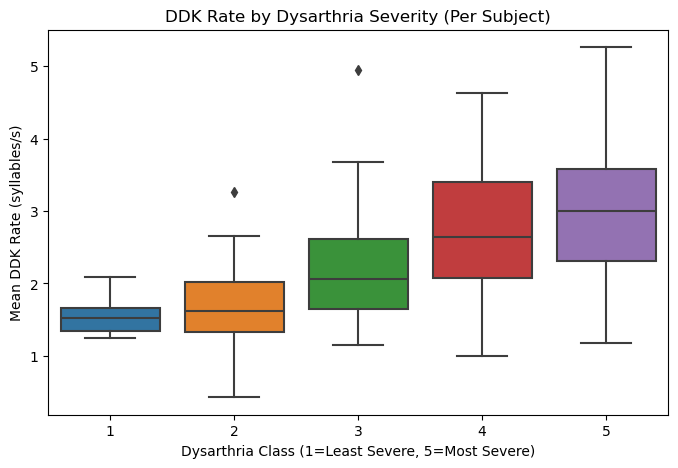

In [18]:
# --- 13. Master Feature Consolidation and Aggregation ---
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

# --- Config ---
BASE_DIR = r"Train/task1"

PATH_MFCC = os.path.join(BASE_DIR, "final_features_task1.csv")           # Articulatory
PATH_PHON = os.path.join(BASE_DIR, "phonatory_features_completed.csv")   # Phonatory
PATH_DDK = os.path.join(BASE_DIR, "ddk_features.csv")                    # Temporal
OUTPUT_MASTER = os.path.join(BASE_DIR, "Task1_MASTER_FEATURES.csv")

def master_merge():
    print("🔄 Loading datasets...")
    
    # Load all 3 feature sets
    try:
        df_mfcc = pd.read_csv(PATH_MFCC)
        df_phon = pd.read_csv(PATH_PHON)
        df_ddk = pd.read_csv(PATH_DDK)
    except FileNotFoundError as e:
        print(f"❌ Missing file: {e}. Cannot proceed with final merge.")
        return

    # --- Aggregation Strategy (Mean across all files per ID) ---
    print("🔄 Aggregating by Subject ID...")
    
    # 1. MFCC/VSA/FCR Aggregation
    # Group by ID and Class (since Class is a target variable, we ensure it's maintained)
    # Note: VSA/FCR columns were already merged onto this DF and repeated per task.
    df_mfcc_agg = df_mfcc.groupby(['ID', 'Class']).mean(numeric_only=True).reset_index()
    
    # 2. Phonatory Aggregation
    df_phon_agg = df_phon.groupby(['ID', 'Class']).mean(numeric_only=True).reset_index()
    # Drop redundant columns from the phonatory DF, focusing only on the mean features
    df_phon_agg = df_phon_agg.drop(columns=['Age', 'Task'], errors='ignore')
    
    # 3. DDK Aggregation
    # DDK features are typically only available for DDK tasks, so we aggregate by ID.
    df_ddk_agg = df_ddk.groupby(['ID']).mean(numeric_only=True).reset_index()
    # Drop 'Task' from DDK aggregate
    df_ddk_agg = df_ddk_agg.drop(columns=['Task'], errors='ignore')
    
    # --- Merging ---
    print("🔄 Joining tables...")
    
    # Start with MFCC (Articulatory), merge Phonatory
    df_master = pd.merge(df_mfcc_agg, df_phon_agg, on=['ID', 'Class'], how='outer', suffixes=('_art', '_phon'))
    
    # Merge DDK (Temporal)
    # Note: Since DDK files only cover a subset of tasks, DDK features will be NaN for non-DDK-performing patients.
    df_master = pd.merge(df_master, df_ddk_agg, on='ID', how='left')
    
    # Fill NaNs with 0 (Standard approach when missing data is treated as zero signal/activity)
    df_master = df_master.fillna(0)
    
    # Verify final shape - Should be number of unique IDs
    print(f"✅ Final Shape: {df_master.shape} (Rows = Unique Subjects)")
    
    df_master.to_csv(OUTPUT_MASTER, index=False)
    print(f"💾 Saved Master Dataset to: {OUTPUT_MASTER}")

    # --- Plot Check ---
    # Quick visual check of a key DDK feature by class
    if 'DDK_Rate' in df_master.columns:
        plt.figure(figsize=(8, 5))
        sns.boxplot(x='Class', y='DDK_Rate', data=df_master)
        plt.title("DDK Rate by Dysarthria Severity (Per Subject)")
        plt.xlabel("Dysarthria Class (1=Least Severe, 5=Most Severe)")
        plt.ylabel("Mean DDK Rate (syllables/s)")
        plt.savefig(os.path.join(BASE_DIR, "check_ddk_distribution_per_subject.png"))
        print("📊 Saved check plot: check_ddk_distribution_per_subject.png")

if __name__ == "__main__":
    master_merge()

# XGBoost Model Training with SMOTE

In [20]:
!pip install xgboost scikit-learn imbalanced-learn matplotlib seaborn

✅ Data loaded successfully
✅ Stratified split done
🚀 Training XGBoost...

--- Model Evaluation (Test Set) ---
Accuracy : 0.3818
Macro F1 : 0.2541

Classification Report:
              precision    recall  f1-score   support

           1     0.0000    0.0000    0.0000         1
           2     0.3333    0.2000    0.2500         5
           3     0.3571    0.4167    0.3846        12
           4     0.1250    0.0667    0.0870        15
           5     0.4828    0.6364    0.5490        22

    accuracy                         0.3818        55
   macro avg     0.2596    0.2639    0.2541        55
weighted avg     0.3354    0.3818    0.3500        55


💾 Top features saved to: Train/task1\xgb_top_features.csv


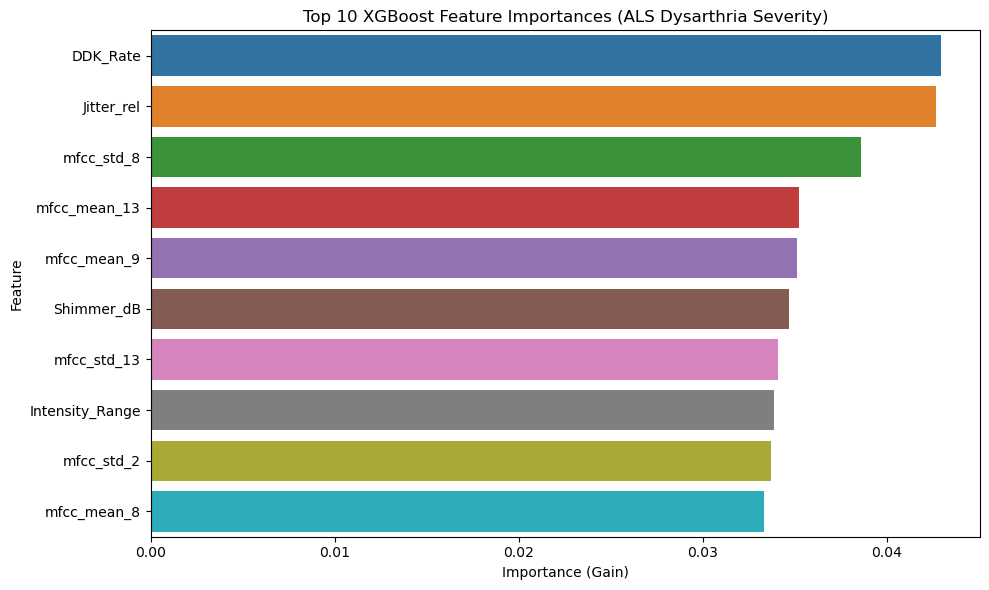

📊 Feature importance plot saved: Train/task1\xgb_feature_importance.png
--------------------------------------------------


In [23]:
# --- Final XGBoost Execution (Corrected & Stable) ---

import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---
BASE_DIR = r"Train/task1"
INPUT_MASTER = os.path.join(BASE_DIR, "Task1_MASTER_FEATURES.csv")

# --- 1. Load Data ---
df = pd.read_csv(INPUT_MASTER)
print("✅ Data loaded successfully")

X = df.drop(columns=['ID', 'Class'])
y = df['Class'] - 1   # Classes 1–5 → 0–4 (required for XGBoost)

# --- 2. Stratified Train-Test Split (NO SMOTE) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("✅ Stratified split done")

# --- 3. XGBoost Model (Reference-aligned ✅) ---
xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    n_estimators=500,
    learning_rate=0.05,
    eval_metric='mlogloss',
    random_state=42,
    min_child_weight=1,
    gamma=0.1
)

print("🚀 Training XGBoost...")
xgb_model.fit(X_train, y_train)

# --- 4. Prediction ---
y_pred = xgb_model.predict(X_test)

# --- 5. Evaluation ---
macro_f1 = f1_score(y_test, y_pred, average='macro')
acc = accuracy_score(y_test, y_pred)

print("\n--- Model Evaluation (Test Set) ---")
print(f"Accuracy : {acc:.4f}")
print(f"Macro F1 : {macro_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test + 1, y_pred + 1, digits=4))

# --- 6. Feature Importance ---
feat_imp = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top_n = 10
top_features = feat_imp.head(top_n)

# Save importance
out_csv = os.path.join(BASE_DIR, "xgb_top_features.csv")
top_features.to_csv(out_csv, header=["Importance"])
print(f"\n💾 Top features saved to: {out_csv}")

# --- 7. Visualization ---
plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_features.values,
    y=top_features.index,
)
plt.title("Top 10 XGBoost Feature Importances (ALS Dysarthria Severity)")
plt.xlabel("Importance (Gain)")
plt.ylabel("Feature")
plt.tight_layout()

out_png = os.path.join(BASE_DIR, "xgb_feature_importance.png")
plt.savefig(out_png)
plt.show()

print(f"📊 Feature importance plot saved: {out_png}")
print("-" * 50)


In [25]:
# --- 13. Hyperparameter Tuning (STABLE VERSION: NO SMOTE) ---

import os
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, make_scorer
from scipy.stats import uniform, randint
import warnings

warnings.filterwarnings("ignore")

# --- Configuration ---
BASE_DIR = r"Train/task1"
INPUT_MASTER = os.path.join(BASE_DIR, "Task1_MASTER_FEATURES.csv")
OUTPUT_TUNED_MODEL = os.path.join(BASE_DIR, "xgb_tuned_model.json")

# --- 1. Load Data ---
df = pd.read_csv(INPUT_MASTER)

X = df.drop(columns=['ID', 'Class'])
y = df['Class'] - 1  # 1–5 → 0–4

print(f"✅ Loaded {X.shape[0]} samples")

# --- 2. Model Definition ---
xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    eval_metric='mlogloss',
    random_state=42,
    tree_method='hist'
)

# --- 3. Hyperparameter Search Space ---
param_dist = {
    'n_estimators': randint(200, 600),
    'learning_rate': uniform(0.02, 0.18),
    'max_depth': randint(3, 7),
    'min_child_weight': randint(1, 5),
    'gamma': uniform(0.0, 0.4),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3)
}

# --- 4. Cross-Validation Strategy ---
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scorer = make_scorer(f1_score, average='macro')

# --- 5. Randomized Search ---
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,
    scoring=scorer,
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=1   # ✅ VERY IMPORTANT (prevents threadpool crash)
)

print("🚀 Starting stable Randomized Search...")
random_search.fit(X, y)

# --- 6. Best Model ---
print("\n--- Tuning Results ---")
print(f"Best Macro F1 (CV): {random_search.best_score_:.4f}")
print("Best Parameters:")
print(random_search.best_params_)

# --- 7. Save Best Model ---
best_model = random_search.best_estimator_
best_model.save_model(OUTPUT_TUNED_MODEL)

print(f"\n💾 Tuned XGBoost model saved at: {OUTPUT_TUNED_MODEL}")


✅ Loaded 272 samples
🚀 Starting stable Randomized Search...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

--- Tuning Results ---
Best Macro F1 (CV): 0.3768
Best Parameters:
{'colsample_bytree': 0.9720485324637261, 'gamma': 0.10885289975385413, 'learning_rate': 0.13658422169744522, 'max_depth': 3, 'min_child_weight': 4, 'n_estimators': 432, 'subsample': 0.7914343774474086}

💾 Tuned XGBoost model saved at: Train/task1\xgb_tuned_model.json
